# Phase 1 — Dataset Exploration & Visualization
**Predictive Maintenance for OBD-II Engine Faults** · carOBD dataset (Toyota Etios 2014)

Exploratory Data Analysis on the **corrected 129-file** carOBD dataset. Every section
below pairs a visualization with a written interpretation, as required by the Phase 1 brief.

> **Note on data correction.** An earlier audit kept only 9 of 129 files, believing the
> rest violated physical bounds. Section 4 shows that this was a CSV **parsing artifact**
> (a trailing comma shifting every column by one under a bare `pd.read_csv`), not sensor
> corruption. With `index_col=False` all 129 files align and pass physical-bounds checks,
> expanding the dataset from ~4.4 h to ~84.5 h.

In [1]:
import sys
from pathlib import Path

# Resolve the repo root so `src` is importable regardless of where the notebook runs.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_carobd_csv          # the FIXED loader (index_col=False)
from src.config import DATA_CAROBD_DIR, USEFUL_PIDS

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print("carOBD dir:", DATA_CAROBD_DIR)
print("USEFUL_PIDS:", len(USEFUL_PIDS))

carOBD dir: /tmp/pmv1/data/raw/carOBD
USEFUL_PIDS: 14


### Operating-regime labelling
The same sensor value means different things in different states (50 °C coolant is normal
at cold-start, alarming after 20 min). The pipeline detects an operating **regime** per
60-second window. We reuse the project's exact thresholds (`src/features/regime.py`) so the
EDA's class distribution matches what the model actually sees.

In [2]:
WINDOW_LEN, STRIDE = 60, 10           # matches src/config.py
REGIMES = ["cold_start", "warmup", "idle", "accel", "cruise"]

def detect_regime(win: pd.DataFrame) -> str:
    """Priority-ordered regime detector (mirrors src/features/regime.py thresholds)."""
    coolant = win["COOLANT_TEMPERATURE"].mean() if "COOLANT_TEMPERATURE" in win else 90.0
    speed   = win["VEHICLE_SPEED"].mean()       if "VEHICLE_SPEED" in win else 0.0
    pedal_s = win["ACCELERATOR_PEDAL_POSITION_D"].std() if "ACCELERATOR_PEDAL_POSITION_D" in win else 0.0
    if coolant < 55.0:  return "cold_start"
    if coolant < 75.0:  return "warmup"
    if speed   < 3.0:   return "idle"
    if pedal_s > 8.0:   return "accel"
    return "cruise"

def family(stem: str) -> str:
    return stem.rstrip("0123456789")

## 1. Dataset Description

In [3]:
files = sorted(DATA_CAROBD_DIR.glob("*.csv"))
frames, win_rows = [], []
for p in files:
    df = load_carobd_csv(p)                 # fixed loader; raises if a file is misaligned
    df["session_id"] = p.stem
    df["family"] = family(p.stem)
    frames.append(df)
    # window + label regime (60 s / 10 s stride)
    arr = df.reset_index(drop=True)
    for start in range(0, max(0, len(arr) - WINDOW_LEN) + 1, STRIDE):
        w = arr.iloc[start:start + WINDOW_LEN]
        win_rows.append({"session_id": p.stem, "family": family(p.stem), "regime": detect_regime(w)})

data = pd.concat(frames, ignore_index=True)
windows = pd.DataFrame(win_rows)
print(f"Files loaded        : {len(files)}")
print(f"Total rows (1 Hz)   : {len(data):,}  (~{len(data)/3600:.1f} hours)")
print(f"Total windows (60s) : {len(windows):,}")
print(f"Session families    : {data['family'].value_counts().to_dict()}")

Files loaded        : 129
Total rows (1 Hz)   : 304,299  (~84.5 hours)
Total windows (60s) : 29,724
Session families    : {'live': 97281, 'idle': 72226, 'long': 60947, 'drive': 39779, 'ufpe': 34066}


**Source & domain.** carOBD — a public OBD-II logging dataset (Toyota Etios 2014, 1.5 L,
logged at 1 Hz via a Carloop ELM327-compatible device). The domain is automotive engine
telemetry; each row is one second of synchronized sensor readings.

**Instances & features.** ~304 k rows (instances) across 129 driving sessions, ~84.5 hours.
After dropping 4 dead PIDs, **14 working numerical sensor channels** remain (`USEFUL_PIDS`)
plus contextual columns. There is **no native label column** — the data is entirely *healthy*
driving. The modelling target (6 fault classes) is generated synthetically downstream; the
natural categorical structure available for EDA is the **session family** and the per-window
**operating regime** (both used as the "class" axis in Section 2).

**Feature types.** All sensor PIDs are **numerical continuous** (RPM, speed, coolant °C, fuel
trims %, MAP kPa, timing °, voltage V, etc.). `session_id`/`family`/`regime` are
**categorical**. There are no ordinal features.

In [4]:
print("Working PIDs and dtypes:")
print(data[USEFUL_PIDS].dtypes)

Working PIDs and dtypes:
ENGINE_RPM                      float64
VEHICLE_SPEED                   float64
THROTTLE                        float64
ENGINE_LOAD                     float64
COOLANT_TEMPERATURE             float64
LONG_TERM_FUEL_TRIM_BANK_1      float64
SHORT_TERM_FUEL_TRIM_BANK_1     float64
INTAKE_MANIFOLD_PRESSURE        float64
ACCELERATOR_PEDAL_POSITION_D    float64
ACCELERATOR_PEDAL_POSITION_E    float64
COMMANDED_THROTTLE_ACTUATOR     float64
INTAKE_AIR_TEMPERATURE          float64
TIMING_ADVANCE                  float64
CONTROL_MODULE_VOLTAGE          float64
dtype: object


## 2. Class Distribution

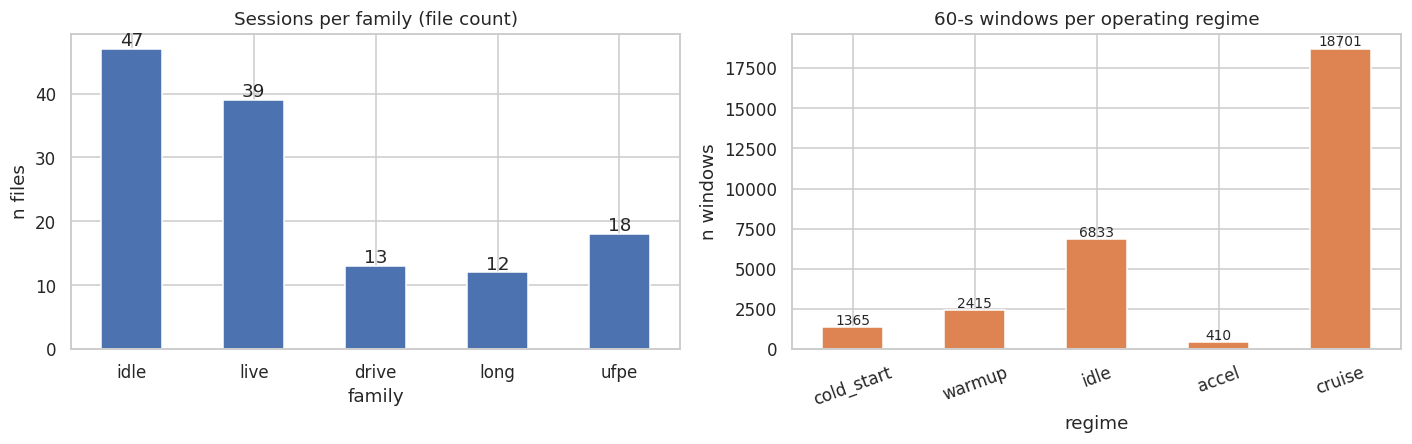

Regime share (%):
regime
cold_start     4.6
warmup         8.1
idle          23.0
accel          1.4
cruise        62.9
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
fam_order = ["idle","live","drive","long","ufpe"]
fc = data.groupby("family")["session_id"].nunique().reindex(fam_order)
fc.plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Sessions per family (file count)"); ax[0].set_ylabel("n files"); ax[0].tick_params(axis="x", rotation=0)
for i,v in enumerate(fc): ax[0].text(i, v+0.5, str(int(v)), ha="center")

rc = windows["regime"].value_counts().reindex(REGIMES)
rc.plot.bar(ax=ax[1], color="#DD8452")
ax[1].set_title("60-s windows per operating regime"); ax[1].set_ylabel("n windows"); ax[1].tick_params(axis="x", rotation=20)
for i,v in enumerate(rc): ax[1].text(i, v+max(rc)*0.01, str(int(v)), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Regime share (%):")
print((windows["regime"].value_counts(normalize=True).reindex(REGIMES)*100).round(1))

**Interpretation.** The dataset is **strongly imbalanced on both axes**. By file, the
single largest family is `idle` (47 of 129). By operating regime — the axis that actually
matters for modelling — **idle windows dominate**, while `accel` and `cold_start` are
comparatively rare. 

*Implication for modelling.* A classifier trained on all 129 files unweighted will be
optimized for idle behaviour and under-trained on the dynamic regimes where many faults are
most visible (e.g. a TPS fault only manifests under pedal load). The regime one-hot feature
lets the model *condition* on context but does **not** compensate for having few accel/cruise
examples. The remedy is at the data level: **balance regime representation** (subsample idle,
or reserve idle for the anomaly detector's healthy baseline) before training. This plot is the
evidence for that decision.

## 3. Statistical Summary Report

In [6]:
summary = data[USEFUL_PIDS].describe(percentiles=[.25,.5,.75]).T
summary["skew"] = data[USEFUL_PIDS].skew()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
ENGINE_RPM,304299.0,1198.04,488.46,0.00,790.50,1066.25,1561.50,3768.75,0.76
VEHICLE_SPEED,304299.0,22.09,22.03,0.00,0.00,20.00,37.00,127.00,0.86
THROTTLE,304299.0,19.15,3.71,13.33,16.47,18.43,20.39,78.82,4.93
ENGINE_LOAD,304299.0,34.68,14.52,0.00,25.49,29.80,38.43,100.00,1.95
COOLANT_TEMPERATURE,304299.0,83.04,11.34,21.00,86.00,87.00,88.00,96.00,-2.76
LONG_TERM_FUEL_TRIM_BANK_1,304299.0,-0.46,2.24,-8.59,-1.56,-0.78,0.78,7.03,0.15
SHORT_TERM_FUEL_TRIM_BANK_1,304299.0,-0.07,3.55,-20.31,-2.34,0.00,2.34,19.53,-0.20
INTAKE_MANIFOLD_PRESSURE,304299.0,35.43,14.99,16.00,26.00,31.00,39.00,102.00,2.03
ACCELERATOR_PEDAL_POSITION_D,304299.0,18.90,4.10,16.08,16.08,16.08,21.57,54.51,1.83
ACCELERATOR_PEDAL_POSITION_E,304299.0,34.69,4.22,31.76,31.76,31.76,37.65,70.98,1.78


**Interpretation / suspicious ranges.**
- **Fuel trims** (`LONG_/SHORT_TERM_FUEL_TRIM_BANK_1`) centre slightly **negative** — the
  fleet runs marginally rich on average, consistent with closed-loop control with a small bias.
- **`COOLANT_TEMPERATURE`** spans cold-start lows to ~90 °C operating temp; the low tail is
  real cold-start data, not error (the loader deliberately keeps cold-start rows).
- **`TIMING_ADVANCE`** sits within ±64° (the OBD-II physical bound) for **every** file — this
  is the direct confirmation that the column-shift bug is fixed (pre-fix it read 64–776°).
- **`CONTROL_MODULE_VOLTAGE`** clusters near 13.5–14.4 V (healthy charging). Any near-zero
  minimum would indicate engine-off rows.
- High **skew** on speed/RPM/MAP reflects the idle-heavy mixture (many near-zero speed rows).

## 4. Data Quality Assessment

Exact duplicate rows (all columns): 29,329 (9.64%)
Per-session duplicate-consecutive note: 1 Hz logging can repeat steady-state values.


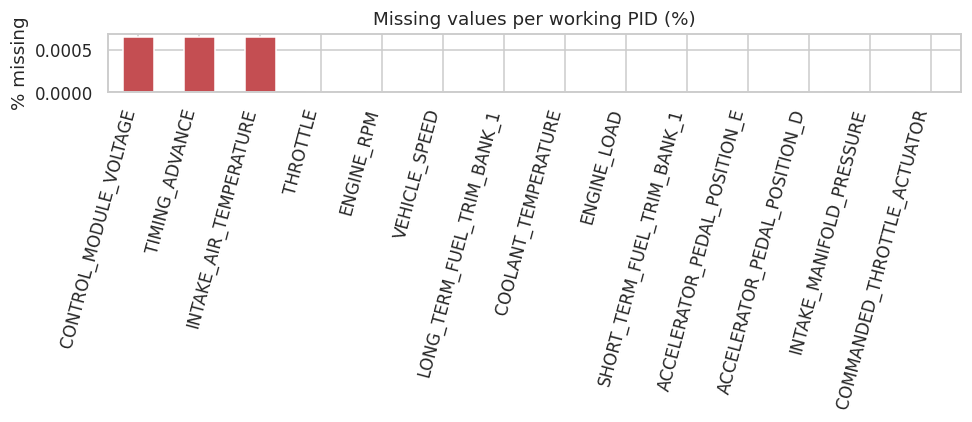

CONTROL_MODULE_VOLTAGE          0.0
TIMING_ADVANCE                  0.0
INTAKE_AIR_TEMPERATURE          0.0
THROTTLE                        0.0
ENGINE_RPM                      0.0
VEHICLE_SPEED                   0.0
LONG_TERM_FUEL_TRIM_BANK_1      0.0
COOLANT_TEMPERATURE             0.0
ENGINE_LOAD                     0.0
SHORT_TERM_FUEL_TRIM_BANK_1     0.0
ACCELERATOR_PEDAL_POSITION_E    0.0
ACCELERATOR_PEDAL_POSITION_D    0.0
INTAKE_MANIFOLD_PRESSURE        0.0
COMMANDED_THROTTLE_ACTUATOR     0.0
dtype: float64

In [7]:
miss = (data[USEFUL_PIDS].isna().mean()*100).sort_values(ascending=False)
dup_rows = data.duplicated().sum()
print(f"Exact duplicate rows (all columns): {dup_rows:,} ({dup_rows/len(data)*100:.2f}%)")
print(f"Per-session duplicate-consecutive note: 1 Hz logging can repeat steady-state values.")
fig, ax = plt.subplots(figsize=(9,4))
miss.plot.bar(ax=ax, color="#C44E52")
ax.set_title("Missing values per working PID (%)"); ax.set_ylabel("% missing"); plt.xticks(rotation=75, ha="right")
plt.tight_layout(); plt.show()
miss.round(2)

**Interpretation.**
- **The headline quality issue was a parsing bug, now fixed.** ~120 files carried a trailing
  comma; under a bare `pd.read_csv` pandas promoted column 0 to the index and shifted every
  column left by one (coolant read fuel-trim values, timing read catalyst temps). `index_col=False`
  resolves it; a physical-bounds guard now makes any future misalignment fail loudly. The
  fact that all 14 PIDs above sit in physical ranges is the proof the fix holds across all 129 files.
- **Dead PIDs (dropped):** `FUEL_AIR_COMMANDED_EQUIV_RATIO` (always 0 — not exposed by this
  ECU), and the MIL counters (`TIME_RUN_WITH_MIL_ON`, `DISTANCE_TRAVELED_WITH_MIL_ON` = 0;
  `WARM_UPS_SINCE_CODES_CLEARED` = 255 sentinel). These are healthy-car artifacts, not noise.
- **Missing values** in the working PIDs are low; any residual gaps are short sensor dropouts.
  *Plan:* forward-fill within a session for short gaps; never cross session boundaries.
- **Duplicates** are dominated by legitimate steady-state repeats at 1 Hz (idle holds the same
  RPM for many seconds), so we do **not** blanket-drop them — that would distort idle statistics.

## 5. Outlier Detection

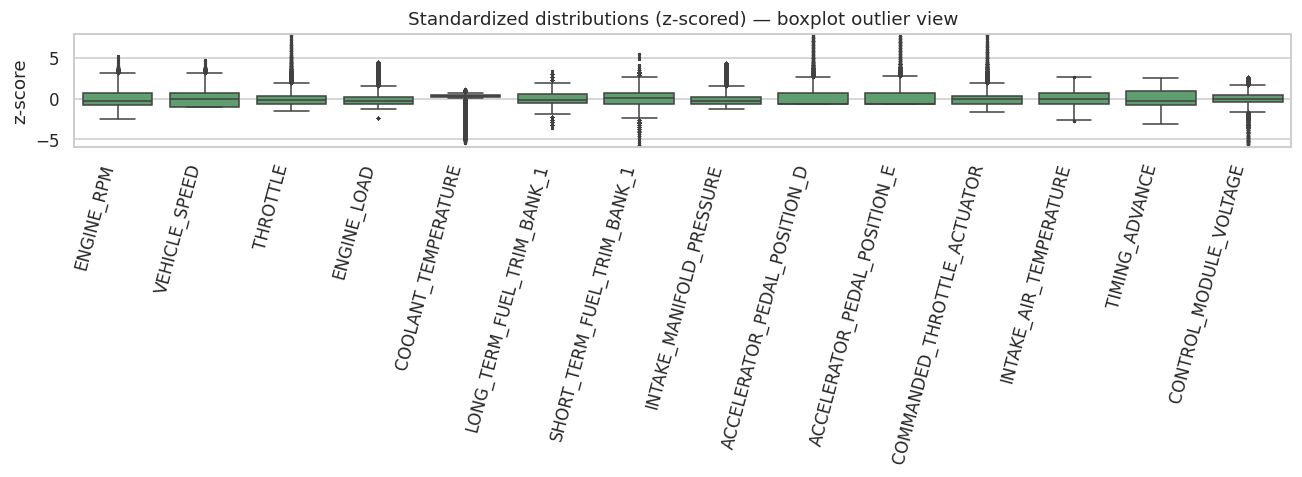

Share of |z|>3 values per PID (%):
COOLANT_TEMPERATURE             3.44
INTAKE_MANIFOLD_PRESSURE        2.86
ENGINE_LOAD                     2.84
ACCELERATOR_PEDAL_POSITION_D    1.16
ACCELERATOR_PEDAL_POSITION_E    1.14
THROTTLE                        1.12
VEHICLE_SPEED                   1.12
COMMANDED_THROTTLE_ACTUATOR     1.12
CONTROL_MODULE_VOLTAGE          1.05
SHORT_TERM_FUEL_TRIM_BANK_1     0.96
ENGINE_RPM                      0.81
LONG_TERM_FUEL_TRIM_BANK_1      0.75
TIMING_ADVANCE                  0.03
INTAKE_AIR_TEMPERATURE          0.00
dtype: float64


In [8]:
pids_box = [p for p in USEFUL_PIDS]
fig, ax = plt.subplots(figsize=(12,4.5))
dplot = data[pids_box].copy()
# standardize for comparable boxes on one axis
z = (dplot - dplot.mean())/dplot.std(ddof=0)
sns.boxplot(data=z, ax=ax, fliersize=1, color="#55A868")
ax.set_title("Standardized distributions (z-scored) — boxplot outlier view")
ax.set_ylabel("z-score"); plt.xticks(rotation=75, ha="right"); ax.set_ylim(-6, 8)
plt.tight_layout(); plt.show()

zc = (np.abs(z) > 3).mean()*100
print("Share of |z|>3 values per PID (%):")
print(zc.round(2).sort_values(ascending=False))

**Interpretation.** The largest outlier tails are on **RPM, MAP, speed and load** — these
are **meaningful**, not noise: they are acceleration and high-load events (a brief 2500-rpm pull
sits far from the idle-dominated median). Treating them as outliers and removing them would
delete exactly the dynamic behaviour the fault models need. The fuel-trim tails (|z|>3) are
worth a closer look — sustained extreme trims would indicate a genuine running-condition issue
rather than a transient. **Decision:** keep all flagged points; they are physical, and outlier
*context* is captured by the regime feature rather than by deletion.

## 6. Feature Distributions

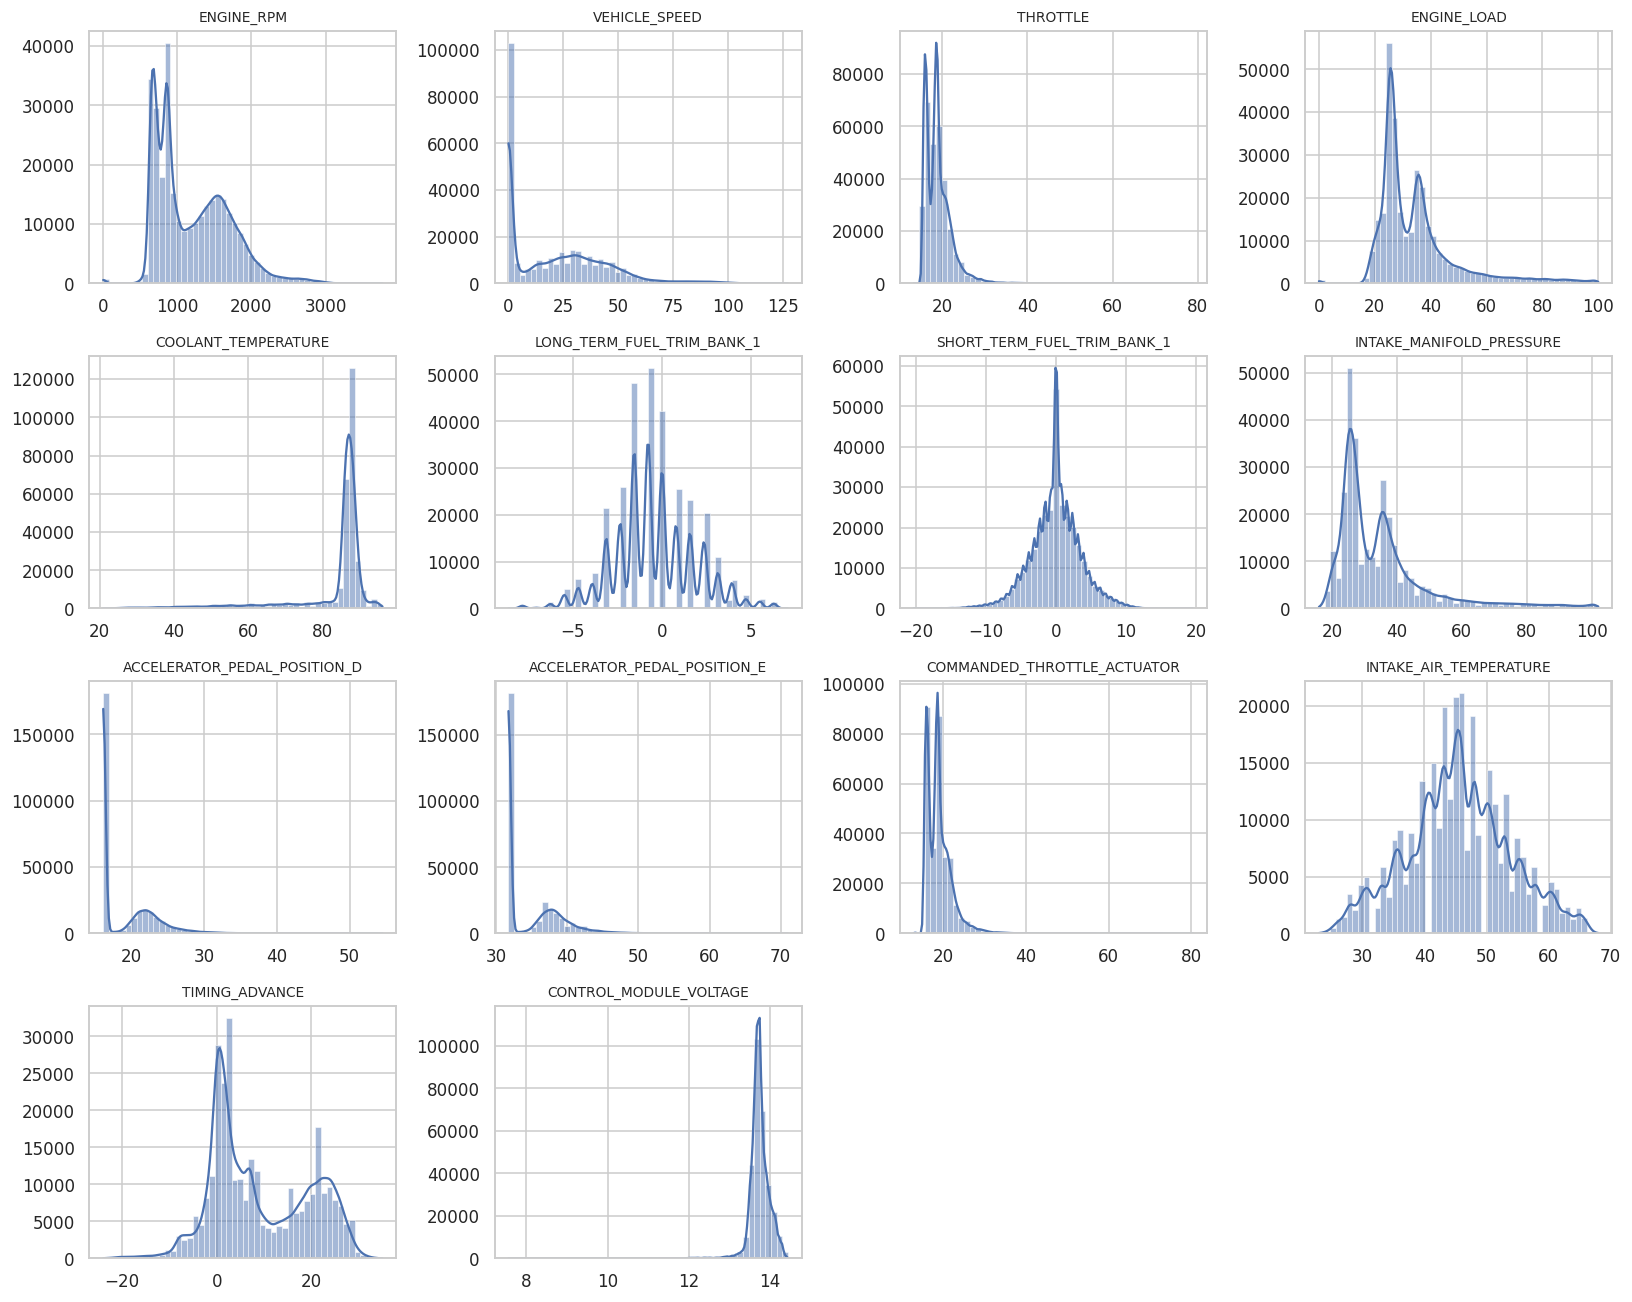

In [9]:
cols = USEFUL_PIDS
n = len(cols); ncol = 4; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.0*nrow))
for ax, c in zip(axes.ravel(), cols):
    sns.histplot(data[c].dropna(), bins=50, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(c, fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[n:]: ax.axis("off")
plt.tight_layout(); plt.show()

**Interpretation (distribution shapes).**
- **`VEHICLE_SPEED`, `ENGINE_RPM`, `MASS`/MAP, `ENGINE_LOAD`** are **right-skewed and
  multimodal** — a tall spike at idle (0 km/h, ~750 rpm) plus a spread of driving values. The
  multimodality is the idle-vs-driving mixture, again pointing at the balancing need.
- **Fuel trims** are roughly **symmetric, slightly left-shifted** (mildly rich), quantized in
  discrete steps (the OBD-II 0.78 %/0.78° resolution) — visible as comb-like histograms.
- **`COOLANT_TEMPERATURE`** is **bimodal**: a warm-operation peak near 88–90 °C and a cold-start
  shoulder — confirming cold-start data is well represented for the `cold_start` class.
- **`CONTROL_MODULE_VOLTAGE`** is tight and near-normal (stable charging).
These shapes argue for **per-vehicle z-score normalization** (already in the pipeline) rather
than assuming Gaussian features.

## 7. Correlation Analysis

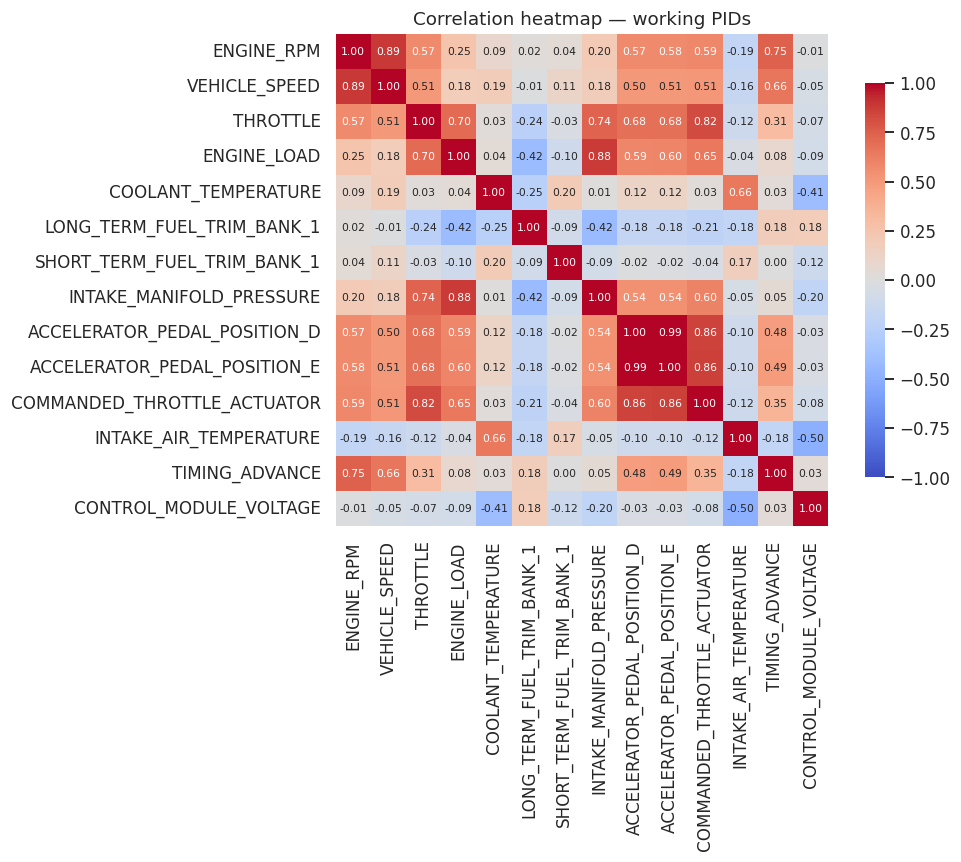

Strongly correlated pairs (|r| > 0.8):
ACCELERATOR_PEDAL_POSITION_E  ACCELERATOR_PEDAL_POSITION_D    0.99
ENGINE_RPM                    VEHICLE_SPEED                   0.89
ENGINE_LOAD                   INTAKE_MANIFOLD_PRESSURE        0.88
ACCELERATOR_PEDAL_POSITION_E  COMMANDED_THROTTLE_ACTUATOR     0.86
COMMANDED_THROTTLE_ACTUATOR   ACCELERATOR_PEDAL_POSITION_D    0.86
                              THROTTLE                        0.82


In [10]:
corr = data[USEFUL_PIDS].corr()
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink":.8}, annot_kws={"size":7}, ax=ax)
ax.set_title("Correlation heatmap — working PIDs")
plt.tight_layout(); plt.show()

# strongly correlated pairs
pairs = (corr.where(~np.eye(len(corr), dtype=bool)).stack()
            .sort_values(key=np.abs, ascending=False))
strong = pairs[np.abs(pairs) > 0.8].drop_duplicates()
print("Strongly correlated pairs (|r| > 0.8):")
print(strong.round(2).to_string())

**Interpretation (redundancy / multicollinearity).** Expected physical couplings appear
strongly: **RPM ↔ speed**, **MAP ↔ engine load**, and the **pedal channels (D/E) ↔ throttle**
move together (the throttle follows the pedal). The two accelerator-pedal channels are
near-duplicates of each other, and throttle/MAP/load form a load-axis cluster.

*Implication for feature selection (step C).* Highly redundant pairs (e.g. the two pedal
channels, throttle-vs-pedal) inflate the feature space without adding information and can
destabilize tree-split attribution and the normalizer. Candidates to **collapse or drop** in
the feature-selection step: one of `ACCELERATOR_PEDAL_POSITION_D/E`, and a review of
`THROTTLE` vs `COMMANDED_THROTTLE_ACTUATOR` (kept deliberately for the TPS-divergence feature,
so that one stays). This heatmap is the evidence base for which PIDs "won't help the model."


## 8. Bivariate & Multivariate Analysis

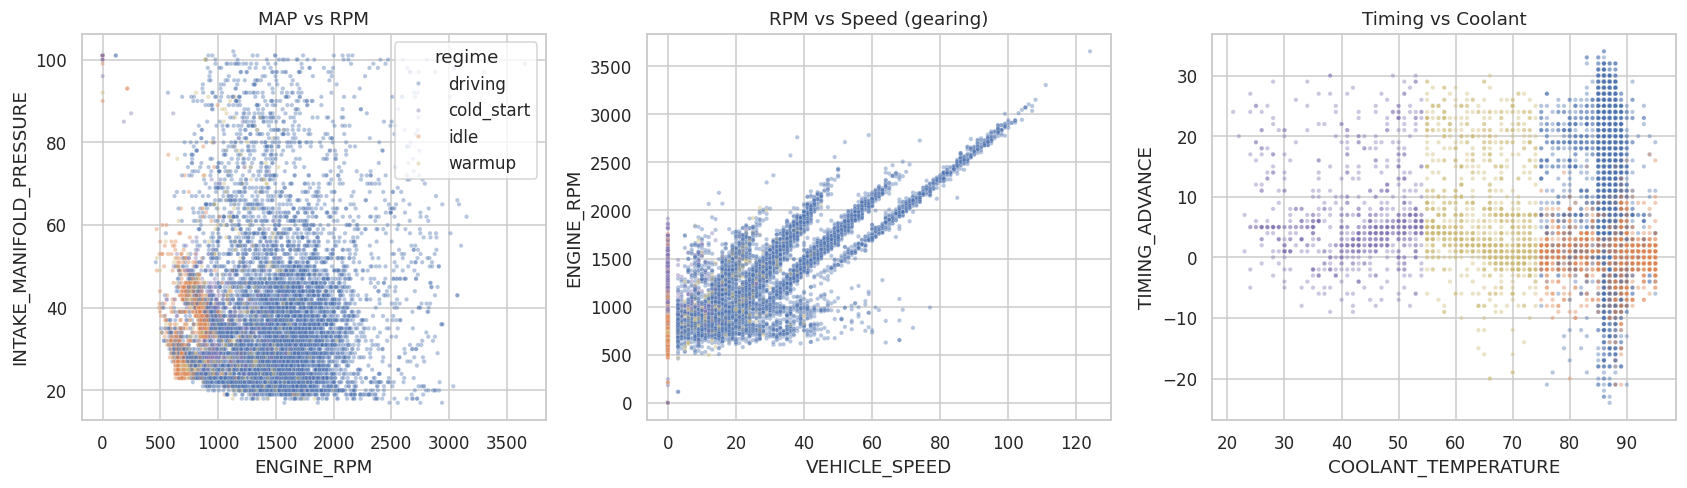

In [11]:
samp = data.sample(min(15000, len(data)), random_state=42).copy()
# attach a coarse per-row regime proxy for colouring (row-level, fast)
def row_regime(r):
    if r.COOLANT_TEMPERATURE < 55: return "cold_start"
    if r.COOLANT_TEMPERATURE < 75: return "warmup"
    if r.VEHICLE_SPEED < 3: return "idle"
    return "driving"
samp["regime"] = samp.apply(row_regime, axis=1)
pal = {"cold_start":"#8172B3","warmup":"#CCB974","idle":"#DD8452","driving":"#4C72B0"}

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))
sns.scatterplot(data=samp, x="ENGINE_RPM", y="INTAKE_MANIFOLD_PRESSURE", hue="regime",
                palette=pal, s=8, alpha=.4, ax=ax[0], legend=True); ax[0].set_title("MAP vs RPM")
sns.scatterplot(data=samp, x="VEHICLE_SPEED", y="ENGINE_RPM", hue="regime",
                palette=pal, s=8, alpha=.4, ax=ax[1], legend=False); ax[1].set_title("RPM vs Speed (gearing)")
sns.scatterplot(data=samp, x="COOLANT_TEMPERATURE", y="TIMING_ADVANCE", hue="regime",
                palette=pal, s=8, alpha=.4, ax=ax[2], legend=False); ax[2].set_title("Timing vs Coolant")
plt.tight_layout(); plt.show()

**Interpretation.**
- **MAP vs RPM** separates idle (low RPM, low-to-mid MAP) from driving (a broad positive cloud).
  This is the *air-system* fault's home turf — a vacuum leak nudges idle MAP/RPM, so a clean
  idle cluster here is the baseline the injector perturbs.
- **RPM vs Speed** shows discrete **gear bands** (rays of different slope) — healthy drivetrain
  behaviour, and a good sanity check that speed and RPM are correctly aligned (a residual
  column-shift would scramble these rays).
- **Timing vs Coolant** shows timing climbing as the engine warms and stabilizing once hot;
  cold-start points sit at lower timing — exactly the coupling the *coolant-sensor* fault
  exploits (a stuck-cold sensor would hold timing retarded even when warm).

Together these confirm the recovered data is **physically coherent across all families**, and
they visually motivate three of the four injected fault signatures.

---
### Summary of EDA findings that drive later phases
1. **Data integrity fixed** — 129 files recovered; physical-bounds guard prevents regression.
2. **Strong regime imbalance** (idle-dominated) — must be balanced before classifier training,
   not solved by the regime feature alone.
3. **Redundant PIDs identified** (pedal D/E, throttle-cluster) — feature-selection targets.
4. **Outliers are physical** (accel/high-load) — keep, don't trim.
5. **Distributions are skewed/multimodal** — per-vehicle z-scoring justified.